# 07_TWITTER-ROBERTA_FINE-TUNE

**Role.** Contextual transformer. Fine-tunes `cardiffnlp/twitter-roberta-base-hate-latest`, a RoBERTa model pretrained on Twitter text and then on hate-speech data, as a single sequence classifier.

**Research questions.** RQ1 as the single-transformer reference. RQ2 as the first contextual model in the attribution comparison. RQ3 as the Twitter- and hate-pretrained lineage: its reliance is compared with other pretraining lineages fine-tuned under the same recipe, and with the ensembles built from it (08, 10, 11). RQ4 through its probability artifact.

**Kaggle inputs.**
1. This repository as an input dataset (provides `tools/notebook_kit.py` and the committed split mirror).
2. The output of `00_create_dataset_and_splits` (the `research_foundation/` folder).
3. Internet on, to download the checkpoint from the Hugging Face Hub. With internet off, attach the checkpoint as a Kaggle model or dataset and set `checkpoint` to its path.

**Accelerator.** GPU (T4 or P100).

**Outputs.**
- `results_summary/07_TWITTER-ROBERTA_FINE-TUNE/` and `research_loop/probs/07_TWITTER-ROBERTA_FINE-TUNE__*`: text-free, copied into the repository.
- `external/07_TWITTER-ROBERTA_FINE-TUNE/`: weights, per-post predictions and per-post attributions. Uploaded to a Kaggle Dataset and recorded in the run manifest; never committed.

**Protocol.** Configurations and the decision threshold are selected on the validation split. The test split is evaluated once, in section 8. Every attribution comes from one method, SHAP's partition explainer over a word-level text masker, so techniques are comparable.

**What this notebook never shows.** Cell outputs are committed, so no cell prints, displays or plots a post, a row id or a text hash. Outputs are counts, metrics, configurations and word-level tables.

**Responsible use.** A research artifact for studying what classifiers of extremist content rely on. Labels are post-level and features are text only; nothing here supports decisions about people, accounts or communities.

## 1. Bootstrap

Locate and load the shared notebook kit (`tools/notebook_kit.py`), then import the libraries this notebook uses. The first block is identical in every notebook.

In [1]:
import importlib.util
import sys
from pathlib import Path

_kit_candidates = (
    sorted(Path("/kaggle/input").rglob("notebook_kit.py"))
    if Path("/kaggle/input").exists()
    else []
)
_kit_candidates += [p / "tools" / "notebook_kit.py" for p in (Path.cwd(), *Path.cwd().parents)]
_kit_path = next((p for p in _kit_candidates if p.is_file()), None)
if _kit_path is None:
    raise FileNotFoundError(
        "notebook_kit.py not found. Attach the repository (or its tools/ folder) "
        "to this kernel as an input dataset."
    )
_kit_spec = importlib.util.spec_from_file_location("notebook_kit", _kit_path)
nk = importlib.util.module_from_spec(_kit_spec)
sys.modules["notebook_kit"] = nk
_kit_spec.loader.exec_module(nk)

import json
import math
import time

import numpy as np
import pandas as pd
import torch
from sklearn.utils.class_weight import compute_class_weight
from torch import nn
from torch.utils.data import DataLoader, Dataset
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    get_linear_schedule_with_warmup,
)

pd.set_option("display.max_columns", 50)

## 2. Configuration

Everything that defines the run is in `CONFIG`. `nk.bootstrap` refuses a configuration whose technique name is not the filename stem, that names a different split or dataset version, or that switches text previews on. It seeds every random number generator and creates the output folders.

In [2]:
CONFIG = {
    # Identity
    "project_name": "extremism_text_classification_comparison",
    "technique_name": "07_TWITTER-ROBERTA_FINE-TUNE",
    "role": "transformer",
    "in_comparison": True,
    "model_family": "fine_tuned_transformer_roberta",
    "feature_family": "contextual_transformer_sequence_representation",
    "dataset_version": "extremism_dataset_clean_v1",
    "split_version": "split_v1_stratified_70_15_15_seed30",
    "random_seed": 30,
    "positive_label": 1,
    "text_normalization_mode": "identity",
    "checkpoint": "cardiffnlp/twitter-roberta-base-hate-latest",
    # Configurations compared on validation. Each is scored at the screening
    # threshold; the decision threshold is selected afterwards, once.
    "ablation": {
        "metric": "accuracy",
        "screening_threshold": 0.5,
        "grid": {
            "learning_rate": [2e-5, 3e-5],
            "num_epochs": [2, 3],
            "batch_size": [8],
            "max_length": [192],
            "weight_decay": [0.01],
            "class_weight": [None, "balanced"],
        },
    },
    # Fixed training recipe. Early stopping monitors validation accuracy at the
    # screening threshold and keeps the weights of the best epoch.
    "training": {
        "gradient_accumulation_steps": 2,
        "warmup_ratio": 0.10,
        "max_grad_norm": 1.0,
        "use_amp_if_cuda": True,
        "early_stopping_patience_epochs": 1,
        "inference_batch_size": 64,
    },
    "threshold": {"metric": "accuracy"},
    # SHAP partition explainer over a word-level masker (set by the kit).
    # Transformer families explain a label-stratified sample of each split.
    "explainer": {
        "max_evals": 500,
        "batch_size": 64,
        "seed": 30,
        "n_posts_per_split": 200,
        "per_member_runs": False,
        "top_k_display": 50,
    },
    # Appendix only: gradient-times-embedding on the explained test sample,
    # aggregated to words, written to external/. Not a committed artifact.
    "gradient_attribution": {"enabled": True},
    "export_coefficients": False,
    "external": {"save_weights": True, "save_predictions": True},
    "error_analysis": {"include_text_preview": False},
}
ctx = nk.bootstrap(CONFIG)

notebook_kit 1.0.0 (sha256 8a408850f14b55f4)
technique: 07_TWITTER-ROBERTA_FINE-TUNE   role: transformer   run_id: 07_TWITTER-ROBERTA_FINE-TUNE_20261008T082627Z
working root: /kaggle/working
  python: 3.12.13
  platform: Linux-6.18.48+-x86_64-with-glibc2.35
  numpy: 2.0.2
  pandas: 2.3.3
  sklearn: 1.6.1
  torch: 2.10.0+cu128
  cuda: True
  gpu: Tesla T4
  shap: 0.51.0


## 3. Load foundation and assert the frozen split

Load the processed dataset and the split assignment written by notebook 00. The kit cross-checks the two files against each other and against the manifest, compares the assignment with the committed mirror when the repository is attached, and stops unless the class counts are exactly train 1309/790, validation 281/169, test 280/170 (non-extremist/extremist).

In [3]:
frame, foundation = nk.load_foundation(ctx)
train_df, val_df, test_df = nk.split_frames(frame)

train_texts = train_df["text"].tolist()
y_train = train_df["label"].to_numpy().astype(int)
val_texts = val_df["text"].tolist()

print("Rows per split:", {"train": len(train_df), "validation": len(val_df), "test": len(test_df)})
print("Input file hashes:", json.dumps(foundation["file_sha256_16"], indent=2))

Frozen split verified (total, negative, positive):
  train      (2099, 1309, 790)
  validation (450, 281, 169)
  test       (450, 280, 170)
Committed split mirrors compared: 2
Rows per split: {'train': 2099, 'validation': 450, 'test': 450}
Input file hashes: {
  "processed_dataset": "5d5c8906772ae262",
  "split_assignments": "d80b760f13e3a9f1",
  "dataset_manifest": "0be435840f1a1209"
}


## 4. Features and model

The model is the pretrained tokenizer and encoder with a two-class classification head, fine-tuned end to end. `predict_proba_texts` maps raw strings to P(EXTREMIST) through the fitted tokenizer and model. It is the single entry point used for the validation threshold, the test evaluation and every explainer run.

Training uses AdamW with linear warmup and decay, gradient accumulation, gradient clipping and mixed precision. Every run starts from the same seed with deterministic cuDNN, a seeded shuffle and no data-loader workers, so a configuration retrained in section 6 follows the same trajectory it followed in section 5. Early stopping keeps the epoch with the highest validation accuracy at the screening threshold.

In [4]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


class TextDataset(Dataset):
    """Strings with integer labels, tokenized per batch by the collate function."""

    def __init__(self, strings, labels):
        self.strings = [str(value) for value in strings]
        self.labels = [int(value) for value in labels]

    def __len__(self):
        return len(self.strings)

    def __getitem__(self, index):
        return self.strings[index], self.labels[index]


def make_train_loader(strings, labels, tokenizer_, batch_size, max_length):
    """A shuffled loader whose order is fixed by the run seed."""

    def collate(batch):
        encoded = tokenizer_(
            [item[0] for item in batch],
            truncation=True,
            padding=True,
            max_length=int(max_length),
            return_tensors="pt",
        )
        encoded["labels"] = torch.tensor([item[1] for item in batch], dtype=torch.long)
        return encoded

    generator = torch.Generator()
    generator.manual_seed(CONFIG["random_seed"])
    return DataLoader(
        TextDataset(strings, labels),
        batch_size=int(batch_size),
        shuffle=True,
        collate_fn=collate,
        num_workers=0,
        generator=generator,
    )


def load_tokenizer_and_model(checkpoint):
    """The pretrained tokenizer and a two-class sequence classifier."""
    tokenizer_ = AutoTokenizer.from_pretrained(checkpoint, use_fast=True)
    model_ = AutoModelForSequenceClassification.from_pretrained(
        checkpoint,
        num_labels=2,
        id2label={0: "NON_EXTREMIST", 1: "EXTREMIST"},
        label2id={"NON_EXTREMIST": 0, "EXTREMIST": 1},
        ignore_mismatched_sizes=True,
    )
    return tokenizer_, model_


def predict_proba_model(model_, tokenizer_, strings, max_length):
    """P(EXTREMIST) for a list of strings under one fitted model."""
    model_.eval()
    batch_size = CONFIG["training"]["inference_batch_size"]
    use_amp = bool(CONFIG["training"]["use_amp_if_cuda"] and DEVICE.type == "cuda")
    strings = [str(value) for value in strings]
    outputs = []
    with torch.no_grad():
        for start in range(0, len(strings), batch_size):
            encoded = tokenizer_(
                strings[start : start + batch_size],
                truncation=True,
                padding=True,
                max_length=int(max_length),
                return_tensors="pt",
            )
            encoded = {key: value.to(DEVICE) for key, value in encoded.items()}
            with torch.autocast(device_type=DEVICE.type, enabled=use_amp):
                logits = model_(**encoded).logits
            outputs.append(torch.softmax(logits.float(), dim=-1)[:, 1].cpu().numpy())
    return np.concatenate(outputs) if outputs else np.zeros(0)


def loss_class_weights(labels, setting):
    """Class weights for the loss: None, or balanced weights from the training labels."""
    if setting is None:
        return None
    if setting != "balanced":
        raise ValueError(f"Unsupported class_weight setting: {setting}")
    weights = compute_class_weight("balanced", classes=np.array([0, 1]), y=np.asarray(labels))
    return torch.tensor(weights, dtype=torch.float32, device=DEVICE)


def train_transformer(hyperparameters, run_label):
    """Fine-tune one configuration on the training split.

    Returns the tokenizer, the model at its best epoch, that epoch's validation
    probabilities, and the training history.
    """
    nk.seed_everything(CONFIG["random_seed"])
    tokenizer_, model_ = load_tokenizer_and_model(CONFIG["checkpoint"])
    model_.to(DEVICE)

    settings = CONFIG["training"]
    loader = make_train_loader(
        train_texts, y_train, tokenizer_, hyperparameters["batch_size"], hyperparameters["max_length"]
    )
    criterion = nn.CrossEntropyLoss(
        weight=loss_class_weights(y_train, hyperparameters["class_weight"])
    )
    optimizer = torch.optim.AdamW(
        model_.parameters(),
        lr=float(hyperparameters["learning_rate"]),
        weight_decay=float(hyperparameters["weight_decay"]),
    )
    accumulation = int(settings["gradient_accumulation_steps"])
    num_epochs = int(hyperparameters["num_epochs"])
    total_updates = max(1, math.ceil(len(loader) / accumulation) * num_epochs)
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(settings["warmup_ratio"] * total_updates),
        num_training_steps=total_updates,
    )
    use_amp = bool(settings["use_amp_if_cuda"] and DEVICE.type == "cuda")
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

    monitor_threshold = CONFIG["ablation"]["screening_threshold"]
    patience = int(settings["early_stopping_patience_epochs"])
    best = {"score": -np.inf, "epoch": None, "state": None, "val_prob": None}
    epochs_without_improvement = 0
    history = []

    for epoch in range(1, num_epochs + 1):
        model_.train()
        epoch_loss = 0.0
        optimizer.zero_grad(set_to_none=True)
        for step, batch in enumerate(loader, start=1):
            batch = {key: value.to(DEVICE) for key, value in batch.items()}
            targets = batch.pop("labels")
            with torch.autocast(device_type=DEVICE.type, enabled=use_amp):
                loss = criterion(model_(**batch).logits.float(), targets) / accumulation
            scaler.scale(loss).backward()
            epoch_loss += float(loss.detach().cpu()) * accumulation
            if step % accumulation == 0 or step == len(loader):
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model_.parameters(), float(settings["max_grad_norm"]))
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()
                optimizer.zero_grad(set_to_none=True)

        epoch_val_prob = predict_proba_model(
            model_, tokenizer_, val_texts, hyperparameters["max_length"]
        )
        epoch_metrics = nk.compute_binary_metrics(y_val, epoch_val_prob, monitor_threshold)
        history.append(
            {
                "run_label": run_label,
                "epoch": epoch,
                "train_loss_mean": epoch_loss / max(1, len(loader)),
                "validation_accuracy_at_screening_threshold": epoch_metrics["accuracy"],
                "validation_positive_f1_at_screening_threshold": epoch_metrics["positive_f1"],
                "validation_pr_auc": epoch_metrics["pr_auc"],
            }
        )
        print(
            f"{run_label} | epoch {epoch}/{num_epochs} | loss {history[-1]['train_loss_mean']:.4f} | "
            f"validation accuracy {epoch_metrics['accuracy']:.4f}"
        )

        if epoch_metrics["accuracy"] > best["score"]:
            best = {
                "score": epoch_metrics["accuracy"],
                "epoch": epoch,
                "state": {k: v.detach().cpu().clone() for k, v in model_.state_dict().items()},
                "val_prob": epoch_val_prob.copy(),
            }
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement > patience:
                break

    model_.load_state_dict(best["state"])
    model_.to(DEVICE)
    return {
        "tokenizer": tokenizer_,
        "model": model_,
        "val_prob": best["val_prob"],
        "best_epoch": best["epoch"],
        "epochs_trained": len(history),
        "history": pd.DataFrame(history),
    }


tokenizer = None  # set in section 6
model = None  # trained in section 6


def predict_proba_texts(texts):
    """P(EXTREMIST) for a list of raw strings, through the fitted tokenizer and model."""
    return predict_proba_model(model, tokenizer, list(texts), best_hyperparameters["max_length"])

## 5. Ablation on validation

Fine-tune every configuration of the grid on the training split and score its best epoch on validation at the screening threshold. The configuration with the highest validation accuracy is selected; ties break on validation ROC-AUC, then on configuration id. Only one model is held in memory at a time. The test split is not touched.

In [5]:
def expand_grid(grid):
    """Every combination of the grid's values, as a list of dicts."""
    keys = list(grid)
    combos = [[]]
    for key in keys:
        combos = [combo + [value] for combo in combos for value in grid[key]]
    return [dict(zip(keys, combo)) for combo in combos]


ablation_configs = expand_grid(CONFIG["ablation"]["grid"])
screening_threshold = CONFIG["ablation"]["screening_threshold"]
y_val = val_df["label"].to_numpy().astype(int)

ablation_rows = []
ablation_histories = []
ablation_start = time.time()
for number, hyperparameters in enumerate(ablation_configs, start=1):
    config_id = f"config_{number:03d}"
    candidate = train_transformer(hyperparameters, run_label=config_id)
    candidate_metrics = nk.evaluate(
        ctx, val_df, candidate["val_prob"], screening_threshold, "validation"
    )
    ablation_rows.append(
        nk.ablation_row(
            ctx,
            config_id,
            hyperparameters,
            candidate_metrics,
            notes=f"best_epoch={candidate['best_epoch']}; epochs_trained={candidate['epochs_trained']}",
        )
    )
    ablation_histories.append(candidate["history"])
    del candidate
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

ablation_results = pd.DataFrame(ablation_rows)
best_row = nk.select_best_config(ablation_results, metric=CONFIG["ablation"]["metric"])
best_hyperparameters = ablation_configs[int(best_row["config_id"].split("_")[1]) - 1]
pd.concat(ablation_histories, ignore_index=True).to_csv(
    ctx.external("training_logs") / "ablation_training_history.csv", index=False
)

print("Device:", DEVICE)
print(f"Configurations compared on validation: {len(ablation_results)}")
print(f"Ablation time: {(time.time() - ablation_start) / 60:.1f} minutes")
print("Selected:", best_row["config_id"], json.dumps(best_hyperparameters))
display(ablation_results.sort_values(["validation_accuracy", "validation_roc_auc"], ascending=False))

config.json:   0%|          | 0.00/888 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/351 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

config_007 | epoch 1/3 | loss 0.5552 | validation accuracy 0.8311
config_007 | epoch 2/3 | loss 0.2639 | validation accuracy 0.8467
config_007 | epoch 3/3 | loss 0.1378 | validation accuracy 0.8600


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-hate-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/tmp/ipykernel_22/3276665335.py:121: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
/tmp/ipykernel_22/3276665335.py:145: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-

config_008 | epoch 1/3 | loss 0.5656 | validation accuracy 0.8400
config_008 | epoch 2/3 | loss 0.2548 | validation accuracy 0.8422
config_008 | epoch 3/3 | loss 0.1332 | validation accuracy 0.8489
Device: cuda
Configurations compared on validation: 8
Ablation time: 8.5 minutes
Selected: config_003 {"learning_rate": 2e-05, "num_epochs": 3, "batch_size": 8, "max_length": 192, "weight_decay": 0.01, "class_weight": null}


,technique,config_id,model_family,feature_family,hyperparameter_summary,threshold,validation_accuracy,validation_balanced_accuracy,validation_positive_f1,validation_f1_macro,validation_roc_auc,validation_pr_auc,notes
2,07_TWITTER-ROBERTA_FINE-TUNE,config_003,fine_tuned_transformer_roberta,contextual_transformer_sequence_representation,"{""batch_size"": 8, ""class_weight"": null, ""learn...",0.5,0.862222,0.856662,0.819767,0.854128,0.927562,0.889922,best_epoch=3; epochs_trained=3
6,07_TWITTER-ROBERTA_FINE-TUNE,config_007,fine_tuned_transformer_roberta,contextual_transformer_sequence_representation,"{""batch_size"": 8, ""class_weight"": null, ""learn...",0.5,0.860000,0.850165,0.813056,0.850578,0.929878,0.897746,best_epoch=3; epochs_trained=3
7,07_TWITTER-ROBERTA_FINE-TUNE,config_008,fine_tuned_transformer_roberta,contextual_transformer_sequence_representation,"{""batch_size"": 8, ""class_weight"": ""balanced"", ...",0.5,0.848889,0.844806,0.804598,0.840705,0.930637,0.898835,best_epoch=3; epochs_trained=3
3,07_TWITTER-ROBERTA_FINE-TUNE,config_004,fine_tuned_transformer_roberta,contextual_transformer_sequence_representation,"{""batch_size"": 8, ""class_weight"": ""balanced"", ...",0.5,0.848889,0.841269,0.801170,0.839653,0.925309,0.886150,best_epoch=3; epochs_trained=3
5,07_TWITTER-ROBERTA_FINE-TUNE,config_006,fine_tuned_transformer_roberta,contextual_transformer_sequence_representation,"{""batch_size"": 8, ""class_weight"": ""balanced"", ...",0.5,0.846667,0.845385,0.804533,0.839195,0.930131,0.890365,best_epoch=2; epochs_trained=2
1,07_TWITTER-ROBERTA_FINE-TUNE,config_002,fine_tuned_transformer_roberta,contextual_transformer_sequence_representation,"{""batch_size"": 8, ""class_weight"": ""balanced"", ...",0.5,0.844444,0.842427,0.801136,0.836700,0.925667,0.889860,best_epoch=2; epochs_trained=2
0,07_TWITTER-ROBERTA_FINE-TUNE,config_001,fine_tuned_transformer_roberta,contextual_transformer_sequence_representation,"{""batch_size"": 8, ""class_weight"": null, ""learn...",0.5,0.844444,0.836531,0.795322,0.834937,0.925130,0.889308,best_epoch=2; epochs_trained=2
4,07_TWITTER-ROBERTA_FINE-TUNE,config_005,fine_tuned_transformer_roberta,contextual_transformer_sequence_representation,"{""batch_size"": 8, ""class_weight"": null, ""learn...",0.5,0.837778,0.826476,0.783383,0.826860,0.931868,0.897224,best_epoch=2; epochs_trained=2


## 6. Final fit

Fine-tune the selected configuration again from the same seed, on the training split only, and keep its best epoch. The model, the tokenizer and the training history are saved under `external/`.

In [6]:
fit_start = time.time()
final_fit = train_transformer(best_hyperparameters, run_label="final")
tokenizer = final_fit["tokenizer"]
model = final_fit["model"]
fit_seconds = time.time() - fit_start

if CONFIG["external"]["save_weights"]:
    model.save_pretrained(ctx.external("weights") / "transformer_model")
    tokenizer.save_pretrained(ctx.external("tokenizer"))
final_fit["history"].to_csv(
    ctx.external("training_logs") / "final_training_history.csv", index=False
)

print("Best epoch:", final_fit["best_epoch"], "of", final_fit["epochs_trained"], "trained")
print(f"Fit time: {fit_seconds / 60:.1f} minutes")
display(final_fit["history"])

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-hate-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/tmp/ipykernel_22/3276665335.py:121: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
/tmp/ipykernel_22/3276665335.py:145: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-

final | epoch 1/3 | loss 0.5707 | validation accuracy 0.8311
final | epoch 2/3 | loss 0.2562 | validation accuracy 0.8444
final | epoch 3/3 | loss 0.1440 | validation accuracy 0.8622


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Best epoch: 3 of 3 trained
Fit time: 1.2 minutes


,run_label,epoch,train_loss_mean,validation_accuracy_at_screening_threshold,validation_positive_f1_at_screening_threshold,validation_pr_auc
0,final,1,0.570655,0.831111,0.750000,0.885880
1,final,2,0.256219,0.844444,0.795322,0.889707
2,final,3,0.143951,0.862222,0.819767,0.889922


## 7. Threshold on validation

Select the decision threshold on the validation split, from the same grid every technique uses (0.05 to 0.95 in steps of 0.005), maximizing validation accuracy. The kit refuses to select a threshold on any other split. The threshold is now locked.

In [7]:
val_prob = predict_proba_texts(val_texts)
threshold, threshold_sweep = nk.select_threshold(
    val_df, val_prob, metric=CONFIG["threshold"]["metric"]
)
validation_metrics = nk.evaluate(ctx, val_df, val_prob, threshold, "validation")

print(f"Threshold selected on validation ({CONFIG['threshold']['metric']}): {threshold:.3f}")
print(json.dumps(validation_metrics, indent=2))

Threshold selected on validation (accuracy): 0.555
{
  "threshold": 0.555,
  "support": 450,
  "positive_support": 169,
  "negative_support": 281,
  "positive_rate": 0.37555555555555553,
  "accuracy": 0.8644444444444445,
  "balanced_accuracy": 0.8584409021036451,
  "precision_macro": 0.854447776111944,
  "recall_macro": 0.8584409021036451,
  "f1_macro": 0.8563210870395863,
  "precision_weighted": 0.8654245099672385,
  "recall_weighted": 0.8644444444444445,
  "f1_weighted": 0.8648240405848583,
  "positive_precision": 0.8103448275862069,
  "positive_recall": 0.834319526627219,
  "positive_f1": 0.8221574344023324,
  "roc_auc": 0.9275621722925309,
  "pr_auc": 0.8899216046608937,
  "brier_score": 0.12186620289266685,
  "tn": 248,
  "fp": 33,
  "fn": 28,
  "tp": 141,
  "false_positive_rate": 0.11743772241992882,
  "false_negative_rate": 0.16568047337278108,
  "technique": "07_TWITTER-ROBERTA_FINE-TUNE",
  "split": "validation"
}


## 8. Single test evaluation

Evaluate the test split once, at the locked threshold. The kit raises if the test split is evaluated a second time in the same run. With 450 test posts, two techniques must differ by about 14 posts before McNemar's test can tell them apart, so this accuracy is a measurement, not a ranking.

In [8]:
test_prob = predict_proba_texts(test_df["text"].tolist())
test_metrics = nk.evaluate(ctx, test_df, test_prob, threshold, "test")

print(json.dumps(test_metrics, indent=2))
display(nk.confusion_matrix_frame(test_metrics))

{
  "threshold": 0.555,
  "support": 450,
  "positive_support": 170,
  "negative_support": 280,
  "positive_rate": 0.37777777777777777,
  "accuracy": 0.8888888888888888,
  "balanced_accuracy": 0.880672268907563,
  "precision_macro": 0.8824721377912867,
  "recall_macro": 0.880672268907563,
  "f1_macro": 0.8815515171934554,
  "precision_weighted": 0.8886637397275695,
  "recall_weighted": 0.8888888888888888,
  "f1_weighted": 0.8887578643943276,
  "positive_precision": 0.8571428571428571,
  "positive_recall": 0.8470588235294118,
  "positive_f1": 0.8520710059171598,
  "roc_auc": 0.9509663865546218,
  "pr_auc": 0.9319517673883265,
  "brier_score": 0.09894152015087651,
  "tn": 256,
  "fp": 24,
  "fn": 26,
  "tp": 144,
  "false_positive_rate": 0.08571428571428572,
  "false_negative_rate": 0.15294117647058825,
  "technique": "07_TWITTER-ROBERTA_FINE-TUNE",
  "split": "test"
}


,actual,predicted,count
0,NON_EXTREMIST,NON_EXTREMIST,256
1,NON_EXTREMIST,EXTREMIST,24
2,EXTREMIST,NON_EXTREMIST,26
3,EXTREMIST,EXTREMIST,144


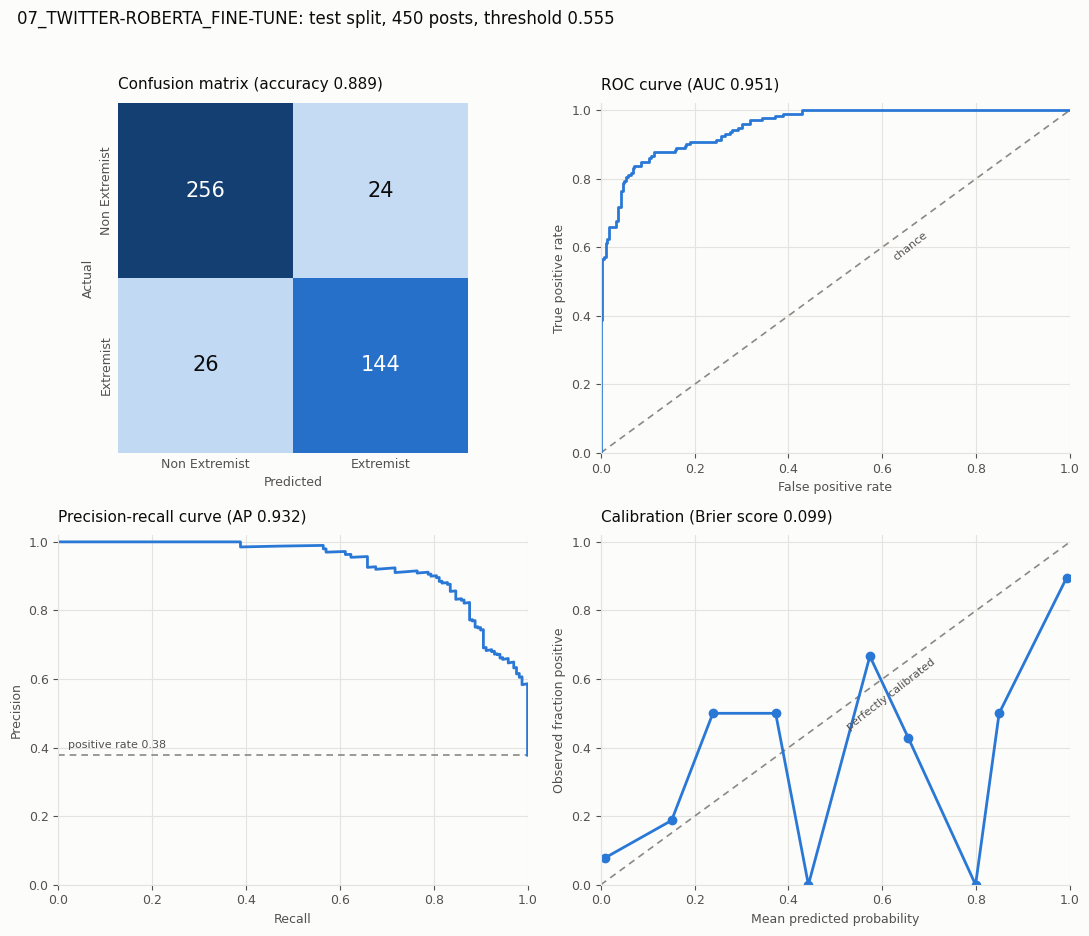

In [9]:
diagnostics_path = nk.plot_diagnostics(ctx, test_df, test_prob, test_metrics)

## 9. Probability artifacts

Write the committed probability artifact: one row per validation and test post with exactly `row_id, split, y_true, y_prob`. Every metric in the result folder, the identity-term false-positive analysis (RQ4) and any later paired test are computed from these files, so a published number can only change when this artifact changes.

In [10]:
probability_paths = nk.export_probabilities(
    ctx,
    val_df,
    val_prob,
    test_df,
    test_prob,
    meta={
        "model_family": CONFIG["model_family"],
        "feature_family": CONFIG["feature_family"],
        "hyperparameters": best_hyperparameters,
        "selected_threshold": threshold,
        "threshold_strategy": nk.THRESHOLD_STRATEGY,
        "threshold_metric": CONFIG["threshold"]["metric"],
    },
)

Probability artifacts written: ['07_TWITTER-ROBERTA_FINE-TUNE__validation.csv', '07_TWITTER-ROBERTA_FINE-TUNE__test.csv', '07_TWITTER-ROBERTA_FINE-TUNE__meta.json']


## 10. Word-level SHAP attribution runs

Explain the fitted model with SHAP's partition explainer over a word-level text masker. The explainer treats the model as a function from text to P(EXTREMIST): it masks words and measures how the probability moves. The same call explains every technique in the repository, which is what makes their attributions comparable.

Each run is reduced to the committed word-level table: for every word, the mean signed and mean absolute attribution over the posts that contain it, and the number of such posts. Two whole-model runs are exported, one over the test split and one over the validation split, so the stability of the result across posts can be measured (RQ3). For transformer families each run explains a label-stratified sample of 200 posts per split, drawn with the run seed; the sample size is recorded in each sidecar.

The per-post token tables go to `external/` only. The tables shown below are word-level.

In [11]:
explainer_settings = CONFIG["explainer"]
explainer_seed = explainer_settings["seed"]

test_sample = nk.sample_for_explanation(
    test_df, explainer_settings["n_posts_per_split"], explainer_seed
)
test_bundle = nk.explain(ctx, predict_proba_texts, test_sample)
test_attributions = nk.export_attribution_run(
    ctx, test_bundle, f"shap-partition_test_seed{explainer_seed}"
)
display(nk.top_words(test_attributions, explainer_settings["top_k_display"]))

Explained 200 of 200 test posts (max_evals=500, seed=30); 0 had no word tokens.
Attribution run 'shap-partition_test_seed30': 1416 words over 200 test posts (member=None).


,word,mean_abs_attribution,mean_attribution,support
0,jew,0.794025,0.794025,1
1,nigger,0.613391,0.613391,2
2,refugeesnotwelcome,0.607725,0.607725,1
3,purity,0.531177,0.531177,1
4,china,0.500908,0.500908,1
5,chong,0.446040,0.446040,3
6,conquer,0.433509,0.433509,1
7,kill,0.432501,0.432501,36
8,burn,0.396165,0.396165,2
9,putinwhore,0.394500,0.394500,1


In [12]:
validation_sample = nk.sample_for_explanation(
    val_df, explainer_settings["n_posts_per_split"], explainer_seed
)
validation_bundle = nk.explain(ctx, predict_proba_texts, validation_sample)
validation_attributions = nk.export_attribution_run(
    ctx, validation_bundle, f"shap-partition_validation_seed{explainer_seed}"
)
display(nk.top_words(validation_attributions, explainer_settings["top_k_display"]))

Explained 200 of 200 validation posts (max_evals=500, seed=30); 0 had no word tokens.
Attribution run 'shap-partition_validation_seed30': 1467 words over 200 validation posts (member=None).


,word,mean_abs_attribution,mean_attribution,support
0,fag,0.593777,0.593777,1
1,mongoloid,0.560108,0.560108,2
2,invade,0.545135,0.545135,1
3,satan,0.525523,0.525523,1
4,asian,0.507377,0.507377,1
5,subhuman,0.492951,0.492951,2
6,global,0.486318,0.486318,1
7,arabs,0.468328,0.468328,1
8,kill,0.444756,0.444756,29
9,fags,0.440418,0.440418,1


## 11. Result folder

Write `results_summary/<technique>/` from the metrics computed above: the selected configuration, validation and test metrics, the confusion matrix, the classification report, the ablation table and the threshold sweep. The kit refuses a folder whose locked threshold differs from the one the metrics were computed at, or whose ablation table has a test column.

In [13]:
best_config = {
    "model_family": CONFIG["model_family"],
    "feature_family": CONFIG["feature_family"],
    "hyperparameters": {
        **best_hyperparameters,
        **CONFIG["training"],
        "checkpoint": CONFIG["checkpoint"],
    },
    "threshold_strategy": nk.THRESHOLD_STRATEGY,
    "threshold_metric": CONFIG["threshold"]["metric"],
    "selected_threshold": threshold,
    "selected_config_id": best_row["config_id"],
    "selection_rule": (
        "highest validation accuracy at the screening threshold; ties on validation ROC-AUC, "
        "then configuration id"
    ),
    "n_validation_candidates": int(len(ablation_results)),
    "validation_uses": ["early_stopping", "config_selection", "threshold"],
    "early_stopping": {
        "monitor": "validation accuracy at the screening threshold",
        "screening_threshold": CONFIG["ablation"]["screening_threshold"],
        "patience_epochs": CONFIG["training"]["early_stopping_patience_epochs"],
        "best_epoch": final_fit["best_epoch"],
        "epochs_trained": final_fit["epochs_trained"],
    },
    "external_pretraining": "Twitter text, then hate-speech data (checkpoint as published)",
    "fit_seconds": fit_seconds,
    "device": str(DEVICE),
}
results_folder = nk.export_results_folder(
    ctx, best_config, validation_metrics, test_metrics, ablation_results, threshold_sweep
)

Result folder written: /kaggle/working/results_summary/07_TWITTER-ROBERTA_FINE-TUNE (7 files)


## 12. External assets

Files that are too large for git or that hold dataset text are written under `external/`: the fitted model, the per-post predictions a reviewer reads, and the per-post attribution tables. For this notebook that also includes the tokenizer and the training histories. The table below is all that is shown here: test outcomes counted by confidence.

In [14]:
if CONFIG["external"]["save_predictions"]:
    nk.export_external_predictions(ctx, val_df, val_prob, test_df, test_prob, threshold)

display(nk.error_counts(test_df, test_prob, threshold))

Per-post predictions written to external/ (hold dataset text; not committed).


,outcome,confidence,count
0,false_negative,0.5-0.6,0
1,false_negative,0.6-0.8,3
2,false_negative,0.8-1.0,23
3,false_positive,0.5-0.6,1
4,false_positive,0.6-0.8,5
5,false_positive,0.8-1.0,18
6,true_negative,0.5-0.6,4
7,true_negative,0.6-0.8,3
8,true_negative,0.8-1.0,249
9,true_positive,0.5-0.6,2


**Appendix: gradient-times-embedding.** Earlier versions of this notebook explained the model with the gradient of the EXTREMIST logit times the input embedding, per subword. That is a local slope at one input, not the effect of removing a word, so it is not comparable with the other techniques and is not a committed artifact. It is kept as a comparison: the same posts explained in section 10 are attributed here, subwords are summed to words, and the result is aggregated with the same function as the SHAP runs. The word table is written to `external/auxiliary/`, and only the agreement between the two methods is shown.

In [15]:
def gradient_x_embedding_words(strings):
    """Per post, (words, values): gradient of the EXTREMIST logit times the input embedding."""
    model.eval()
    embedding_layer = model.get_input_embeddings()
    words_per_post = []
    values_per_post = []
    for value in strings:
        encoded = tokenizer(
            value,
            truncation=True,
            max_length=int(best_hyperparameters["max_length"]),
            return_tensors="pt",
        )
        word_ids = encoded.word_ids(0)
        input_ids = encoded["input_ids"].to(DEVICE)
        attention_mask = encoded["attention_mask"].to(DEVICE)
        embeddings = embedding_layer(input_ids).detach().requires_grad_(True)
        logits = model(inputs_embeds=embeddings, attention_mask=attention_mask).logits
        model.zero_grad(set_to_none=True)
        logits[0, 1].backward()
        subword_scores = (embeddings.grad * embeddings).sum(dim=-1)[0].detach().cpu().numpy()

        words = []
        scores = []
        current_word = None
        for position, word_id in enumerate(word_ids):
            if word_id is None:
                continue
            if word_id != current_word:
                span = encoded.word_to_chars(0, word_id)
                words.append(value[span.start : span.end])
                scores.append(0.0)
                current_word = word_id
            scores[-1] += float(subword_scores[position])
        words_per_post.append(words)
        values_per_post.append(np.asarray(scores))
    return words_per_post, values_per_post


if CONFIG["gradient_attribution"]["enabled"]:
    gradient_words, gradient_values = gradient_x_embedding_words(test_sample["text"].tolist())
    gradient_table = nk.aggregate_word_attributions(gradient_words, gradient_values)
    gradient_table.to_csv(
        ctx.external("auxiliary") / "gradient_x_embedding_words_test.csv", index=False
    )
    both = gradient_table.merge(test_attributions, on="word", suffixes=("_gradient", "_shap"))
    rank_agreement = both["mean_attribution_gradient"].corr(
        both["mean_attribution_shap"], method="spearman"
    )
    sign_agreement = (
        np.sign(both["mean_attribution_gradient"]) == np.sign(both["mean_attribution_shap"])
    ).mean()
    print("Words attributed by both methods:", len(both))
    print(f"Spearman correlation of mean attribution: {rank_agreement:.3f}")
    print(f"Share of words with the same sign: {sign_agreement:.3f}")

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: Memory Efficient attention defaults to a non-deterministic algorithm. To explicitly enable determinism call torch.use_deterministic_algorithms(True, warn_only=False). (Triggered internally at /pytorch/aten/src/ATen/native/transformers/cuda/attention_backward.cu:897.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Words attributed by both methods: 1416
Spearman correlation of mean attribution: -0.077
Share of words with the same sign: 0.478


## 13. Interpretation

This section is written before the run and states how to read the outputs. Numbers are not copied here; they live in the result folder and the rendered tables.

**Reading the outputs.** The word tables in section 10 rank words by mean absolute attribution; the signed mean says whether a word pushes toward EXTREMIST (positive) or away from it. Unlike the linear models, a word's effect here depends on its context, so the mean over posts hides variation that the per-post files in `external/` keep. The pipeline check that licenses comparing these tables with other techniques is the coefficient check on notebook 01 (`tools/validate_shap.py`).

**False positives and false negatives.** The outcome table in section 12 counts each error type by confidence. High-confidence false positives are the cases RQ4 examines: `tools/identity_fpr.py` measures whether they concentrate on non-extremist posts that mention an identity term. Review of individual errors uses the per-post files in `external/`, never a cell output.

**Limitations.**
- The checkpoint was pretrained on Twitter text and then on hate-speech data. That pretraining is part of the experimental condition: this notebook measures what the fine-tuned model relies on, not what pretraining alone contributes. Separating the two needs a control fine-tuned from a checkpoint without that pretraining.
- Attribution runs cover a 200-post sample per split, so words that are rare in the sample have low support. The support column says how many posts each mean rests on.
- The validation split is used three times: to stop training, to select the configuration and to select the threshold.
- GPU fine-tuning is seeded and deterministic flags are set, but results can still differ slightly across GPU models and library versions.
- Labels are post-level and features are text only. The model detects extremist content in a post. It does not detect accounts, intent or radicalization over time.
- One dataset and one 450-post test split. A gap of fewer than about 14 test posts between two techniques is not a detectable difference.
- SHAP attributions describe what moves this model's probability when words are masked. Masked text is unlike real posts, and an attribution is not a causal claim about language.
- Lexicon categories (extremist framing, identity term, slur, topical) are assigned afterwards by `tools/categorize_attributions.py`; no category is assigned in this notebook.

## 14. Package outputs

Inventory the external files with their hashes, check that nothing text-bearing sits in the committed tree, and zip the files that go into the repository. The zip unpacks at the repository root.

**After the run.**
1. Unzip `<technique>_repo_files.zip` at the repository root.
2. Upload `external/<technique>/` to a Kaggle Dataset, then record it: `tools/run_manifest.py init`, then `add-assets-from --file external_assets.json`.
3. Run `tools/validate_results_folder.py --all`, `tools/identity_fpr.py`, `tools/categorize_attributions.py`, `tools/compare_reliance.py`, then `tools/render_tables.py --write`.
4. Before committing this notebook with its outputs, run `tools/check_notebook.py --notebook <file>` and `tools/scan_text_leakage.py`.

In [16]:
nk.finalize(ctx)

Repository files (14), zipped to 07_TWITTER-ROBERTA_FINE-TUNE_repo_files.zip:
  results_summary/07_TWITTER-ROBERTA_FINE-TUNE/ablation_results.csv
  results_summary/07_TWITTER-ROBERTA_FINE-TUNE/attributions/shap-partition_test_seed30.csv
  results_summary/07_TWITTER-ROBERTA_FINE-TUNE/attributions/shap-partition_test_seed30.json
  results_summary/07_TWITTER-ROBERTA_FINE-TUNE/attributions/shap-partition_validation_seed30.csv
  results_summary/07_TWITTER-ROBERTA_FINE-TUNE/attributions/shap-partition_validation_seed30.json
  results_summary/07_TWITTER-ROBERTA_FINE-TUNE/best_config.json
  results_summary/07_TWITTER-ROBERTA_FINE-TUNE/classification_report_test.json
  results_summary/07_TWITTER-ROBERTA_FINE-TUNE/confusion_matrix_test.csv
  results_summary/07_TWITTER-ROBERTA_FINE-TUNE/metrics_test.json
  results_summary/07_TWITTER-ROBERTA_FINE-TUNE/metrics_validation.json
  results_summary/07_TWITTER-ROBERTA_FINE-TUNE/threshold_sweep_validation.csv
  research_loop/probs/07_TWITTER-ROBERTA_FINE-

PosixPath('/kaggle/working/07_TWITTER-ROBERTA_FINE-TUNE_repo_files.zip')